Dataset loaded successfully!

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape:
(20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-N

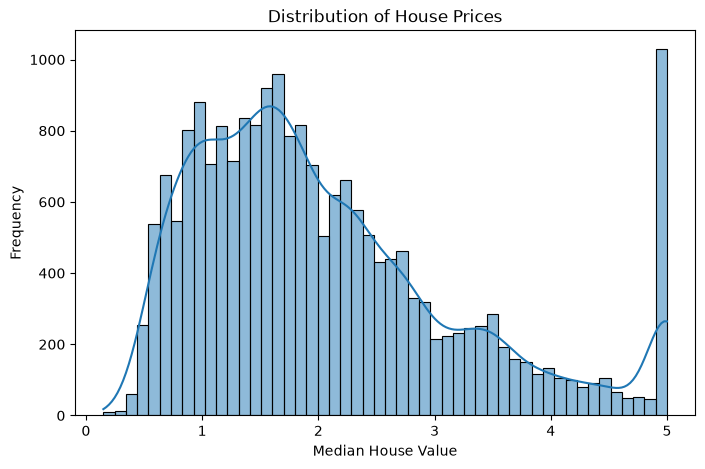

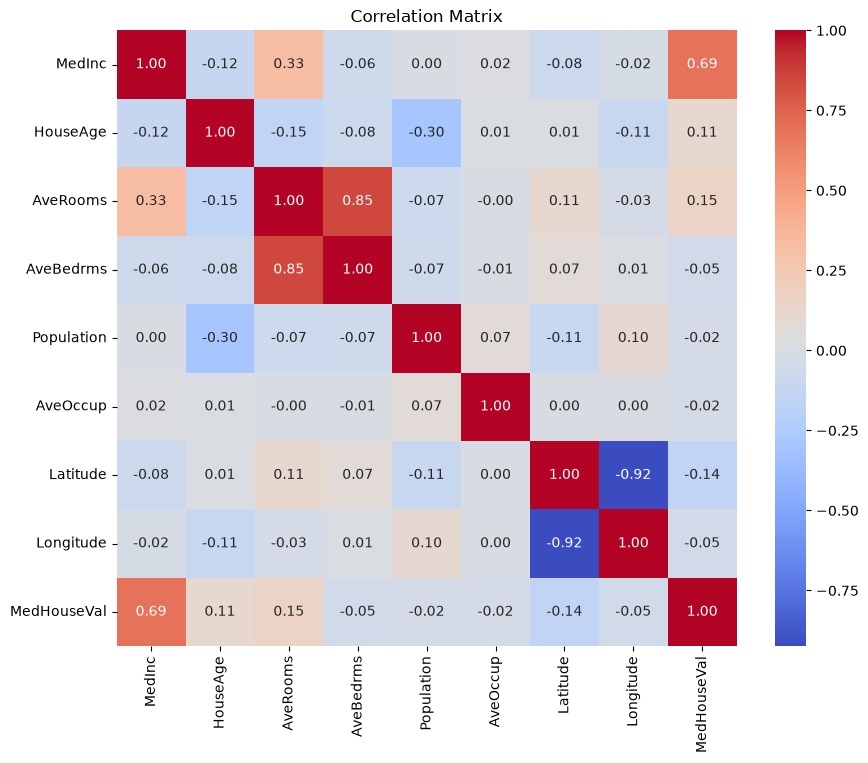

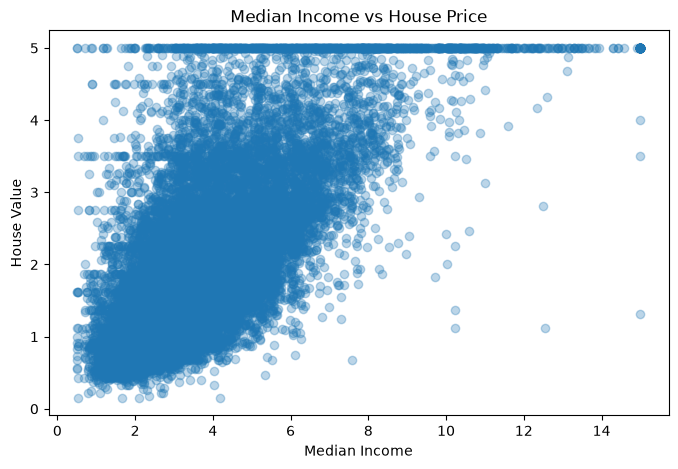


Feature shape:
(20640, 8)

Target shape:
(20640,)

Training data:
(16512, 8)

Testing data:
(4128, 8)

Model training completed!
MODEL EVALUATION
Mean Squared Error (MSE): 0.5558915986952444
Root Mean Squared Error (RMSE): 0.7455813830127764
Mean Absolute Error (MAE): 0.5332001304956565
R² Score: 0.5757877060324508

Actual vs Predicted:
    Actual Price  Predicted Price
0        0.47700         0.719123
1        0.45800         1.764017
2        5.00001         2.709659
3        2.18600         2.838926
4        2.78000         2.604657
5        1.58700         2.011754
6        1.98200         2.645500
7        1.57500         2.168755
8        3.40000         2.740746
9        4.46600         3.915615
10       1.23200         0.938962
11       2.53900         1.901222
12       2.15100         1.758712
13       2.20500         2.250160
14       2.19800         2.540870
15       1.36200         1.917405
16       1.78400         2.386483
17       1.87500         2.010930
18       1.398

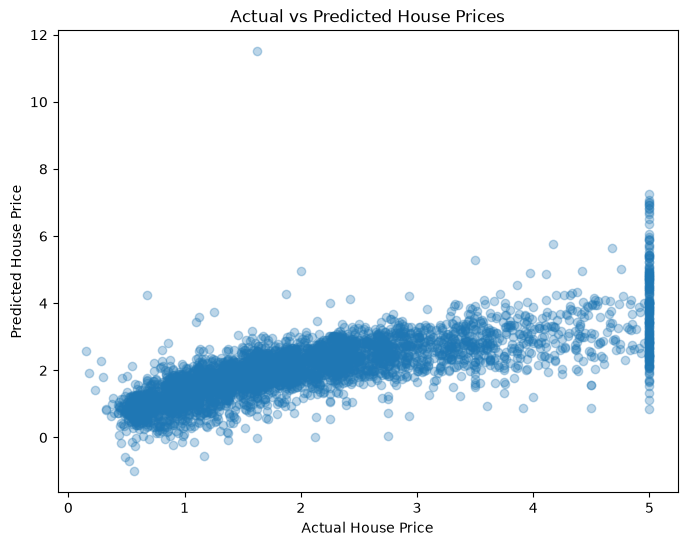


Feature Coefficients:
      Feature  Coefficient
0      MedInc     0.854383
3   AveBedrms     0.339259
1    HouseAge     0.122546
4  Population    -0.002308
5    AveOccup    -0.040829
2    AveRooms    -0.294410
7   Longitude    -0.869842
6    Latitude    -0.896929


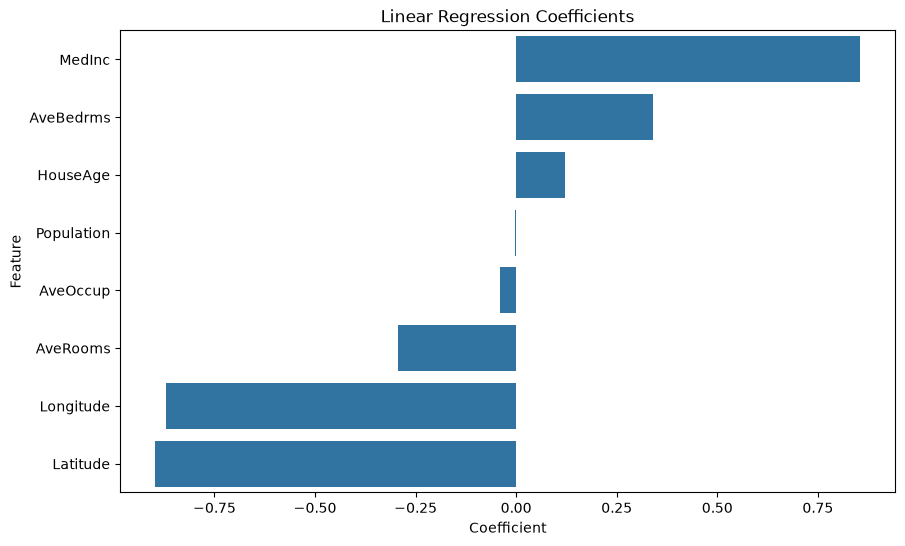

NEW HOUSE PREDICTION
Predicted House Price: $234,978.54


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset loaded successfully!")
print()

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

df = df.fillna(df.median(numeric_only=True))

print("\nMissing values after treatment:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

plt.figure(figsize=(8,5))

sns.histplot(df['MedHouseVal'],bins=50,kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(10,8))

correlation = df.corr()

sns.heatmap(correlation,annot=True,cmap='coolwarm',fmt='.2f')

plt.title("Correlation Matrix")

plt.show()

plt.figure(figsize=(8,5))

plt.scatter(df['MedInc'],df['MedHouseVal'],alpha=0.3)

plt.xlabel("Median Income")
plt.ylabel("House Value")

plt.title("Median Income vs House Price")

plt.show()

X = df.drop('MedHouseVal',axis=1)

y = df['MedHouseVal']

print("\nFeature shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("\nTraining data:")
print(X_train.shape)

print("\nTesting data:")
print(X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train_scaled,y_train)

print("\nModel training completed!")

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test,y_pred)

r2 = r2_score(y_test,y_pred)

print("MODEL EVALUATION") 

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("Mean Absolute Error (MAE):", mae)

print("R² Score:", r2)

results = pd.DataFrame({'Actual Price': y_test.values,'Predicted Price': y_pred})

print("\nActual vs Predicted:")
print(results.head(20))

results['Actual Price ($)'] = (
    results['Actual Price'] * 100000
)

results['Predicted Price ($)'] = (
    results['Predicted Price'] * 100000
)

print("\nPrices in Dollars:")
print(results[['Actual Price ($)','Predicted Price ($)']].head(20))

plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred,alpha=0.3)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

coefficients = pd.DataFrame({'Feature': X.columns,'Coefficient': model.coef_})

coefficients = coefficients.sort_values(by='Coefficient',ascending=False)

print("\nFeature Coefficients:")
print(coefficients)

plt.figure(figsize=(10,6))

sns.barplot(x='Coefficient',y='Feature',data=coefficients)

plt.title("Linear Regression Coefficients")

plt.show()

new_house = pd.DataFrame({
    'MedInc': [5.0],
    'HouseAge': [20],
    'AveRooms': [6],
    'AveBedrms': [1.0],
    'Population': [1000],
    'AveOccup': [3],
    'Latitude': [34.0],
    'Longitude': [-118.0]
})

new_house_scaled = scaler.transform(
    new_house
)

predicted_price = model.predict(
    new_house_scaled
)

price_dollars = (
    predicted_price[0] * 100000
)

print("NEW HOUSE PREDICTION")

print("Predicted House Price: ${:,.2f}".format(price_dollars))